<a href="https://colab.research.google.com/github/EliavR2005/Ejercicio_Modelos_Predictvos/blob/main/AlgoritmosDeAprendizaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/solicitudes_credito_500.csv")
df.head()

,id_solicitud,edad,ingreso_mensual,antiguedad_laboral,historial_crediticio,creditos_activos,utilizacion_credito,pagos_atrasados,monto_solicitado,plazo_meses,riesgo
0,CR-0001,59,31311,5.2,739,3,51.1,0.0,22209,24,0
1,CR-0002,49,10068,4.0,723,2,44.1,2.0,3000,48,0
2,CR-0003,35,36237,9.9,755,4,45.5,0.0,32517,24,0
3,CR-0004,63,11575,12.1,633,4,13.6,0.0,3141,48,1
4,CR-0005,28,10311,14.0,706,1,56.3,1.0,3858,36,0


In [3]:
df.dtypes

,0
id_solicitud,object
edad,int64
ingreso_mensual,int64
antiguedad_laboral,float64
historial_crediticio,int64
creditos_activos,int64
utilizacion_credito,float64
pagos_atrasados,float64
monto_solicitado,int64
plazo_meses,int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_solicitud          500 non-null    object 
 1   edad                  500 non-null    int64  
 2   ingreso_mensual       500 non-null    int64  
 3   antiguedad_laboral    495 non-null    float64
 4   historial_crediticio  500 non-null    int64  
 5   creditos_activos      500 non-null    int64  
 6   utilizacion_credito   495 non-null    float64
 7   pagos_atrasados       496 non-null    float64
 8   monto_solicitado      500 non-null    int64  
 9   plazo_meses           500 non-null    int64  
 10  riesgo                500 non-null    int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 43.1+ KB


Datos faltantes

In [5]:
# Contar valores faltantes por columna
df.isnull().sum()

,0
id_solicitud,0
edad,0
ingreso_mensual,0
antiguedad_laboral,5
historial_crediticio,0
creditos_activos,0
utilizacion_credito,5
pagos_atrasados,4
monto_solicitado,0
plazo_meses,0


In [6]:
#copia de seguridad
df_limpio = df.copy()

In [7]:
# Rellenar valores faltantes con la mediana de cada columna
columnas_numericas = [
    "antiguedad_laboral",
    "utilizacion_credito",
    "pagos_atrasados"
]

for columna in columnas_numericas:
    df_limpio[columna] = df_limpio[columna].fillna(
        df_limpio[columna].median()
    )

In [8]:
# Prueba de limpieza
df_limpio.isnull().sum()

,0
id_solicitud,0
edad,0
ingreso_mensual,0
antiguedad_laboral,0
historial_crediticio,0
creditos_activos,0
utilizacion_credito,0
pagos_atrasados,0
monto_solicitado,0
plazo_meses,0


Prubas para variables de entrada y salida

In [9]:
df.isnull().sum()

,0
id_solicitud,0
edad,0
ingreso_mensual,0
antiguedad_laboral,5
historial_crediticio,0
creditos_activos,0
utilizacion_credito,5
pagos_atrasados,4
monto_solicitado,0
plazo_meses,0


In [10]:
df_limpio.isnull().sum()

,0
id_solicitud,0
edad,0
ingreso_mensual,0
antiguedad_laboral,0
historial_crediticio,0
creditos_activos,0
utilizacion_credito,0
pagos_atrasados,0
monto_solicitado,0
plazo_meses,0


In [11]:
df_limpio.shape

(500, 11)

In [12]:
df_limpio.duplicated().sum()


np.int64(0)

Programacion Tradicional 5 reglas de riesgo

In [13]:
# ------------------------------------------------------------
# REGLA 1: PAGOS ATRASADOS
# ------------------------------------------------------------

# Si el solicitante tiene 3 o más pagos atrasados,
# consideramos que existe una señal de alto riesgo.

def regla_1(pagos_atrasados):
    if pagos_atrasados >= 3:
        return 1  # 1 = Alto riesgo
    else:
        return 0  # 0 = Bajo riesgo

In [14]:
# Probamos la Regla 1 con diferentes cantidades de pagos atrasados.

print("2 pagos atrasados:", regla_1(2))
print("3 pagos atrasados:", regla_1(3))
print("5 pagos atrasados:", regla_1(5))

2 pagos atrasados: 0
3 pagos atrasados: 1
5 pagos atrasados: 1


In [15]:
# ------------------------------------------------------------
# REGLA 2: UTILIZACIÓN DEL CRÉDITO
# ------------------------------------------------------------

# Si el porcentaje de utilización del crédito es 80% o mayor,
# consideramos que la solicitud presenta una señal de alto riesgo.

def regla_2(utilizacion_credito):
    if utilizacion_credito >= 80:
        return 1  # 1 = Alto riesgo
    else:
        return 0  # 0 = Bajo riesgo

In [16]:
# Probamos la Regla 2 con diferentes porcentajes de utilización.

print("Utilización del 50%:", regla_2(50))
print("Utilización del 80%:", regla_2(80))
print("Utilización del 95%:", regla_2(95))

Utilización del 50%: 0
Utilización del 80%: 1
Utilización del 95%: 1


In [17]:
# ------------------------------------------------------------
# REGLA 3: HISTORIAL CREDITICIO
# ------------------------------------------------------------

# Si el historial crediticio es menor a 500,
# consideramos que existe una señal de alto riesgo.

def regla_3(historial_crediticio):
    if historial_crediticio < 500:
        return 1  # 1 = Alto riesgo
    else:
        return 0  # 0 = Bajo riesgo

In [18]:
# Probamos la Regla 3 con diferentes valores de historial crediticio.

print("Historial de 400:", regla_3(400))
print("Historial de 500:", regla_3(500))
print("Historial de 700:", regla_3(700))

Historial de 400: 1
Historial de 500: 0
Historial de 700: 0


In [19]:
# ------------------------------------------------------------
# REGLA 4: CRÉDITOS ACTIVOS
# ------------------------------------------------------------

# Si el solicitante tiene 5 o más créditos activos,
# consideramos que existe una señal de alto riesgo.

def regla_4(creditos_activos):
    if creditos_activos >= 5:
        return 1  # 1 = Alto riesgo
    else:
        return 0  # 0 = Bajo riesgo

In [20]:
# Probamos la Regla 4 con diferentes cantidades
# de créditos activos.

print("3 créditos activos:", regla_4(3))
print("5 créditos activos:", regla_4(5))
print("7 créditos activos:", regla_4(7))

3 créditos activos: 0
5 créditos activos: 1
7 créditos activos: 1


In [21]:
# ------------------------------------------------------------
# REGLA 5: MONTO SOLICITADO VS. INGRESO MENSUAL
# ------------------------------------------------------------

# Comparamos el monto que solicita el cliente
# con su ingreso mensual.
#
# Si solicita más dinero del que recibe mensualmente,
# consideramos que existe una señal de alto riesgo.

def regla_5(monto_solicitado, ingreso_mensual):
    if monto_solicitado > ingreso_mensual:
        return 1  # 1 = Alto riesgo
    else:
        return 0  # 0 = Bajo riesgo

In [22]:
# Probamos la Regla 5 con diferentes combinaciones
# de monto solicitado e ingreso mensual.

print("Solicita $10,000 y gana $15,000:",
      regla_5(10000, 15000))

print("Solicita $15,000 y gana $15,000:",
      regla_5(15000, 15000))

print("Solicita $20,000 y gana $15,000:",
      regla_5(20000, 15000))

Solicita $10,000 y gana $15,000: 0
Solicita $15,000 y gana $15,000: 0
Solicita $20,000 y gana $15,000: 1


In [23]:
df.isnull().sum()

,0
id_solicitud,0
edad,0
ingreso_mensual,0
antiguedad_laboral,5
historial_crediticio,0
creditos_activos,0
utilizacion_credito,5
pagos_atrasados,4
monto_solicitado,0
plazo_meses,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_solicitud          500 non-null    object 
 1   edad                  500 non-null    int64  
 2   ingreso_mensual       500 non-null    int64  
 3   antiguedad_laboral    495 non-null    float64
 4   historial_crediticio  500 non-null    int64  
 5   creditos_activos      500 non-null    int64  
 6   utilizacion_credito   495 non-null    float64
 7   pagos_atrasados       496 non-null    float64
 8   monto_solicitado      500 non-null    int64  
 9   plazo_meses           500 non-null    int64  
 10  riesgo                500 non-null    int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 43.1+ KB


In [25]:
# ============================================================
# 5.2 PREPARACIÓN DE LOS DATOS
# Tratamiento de valores faltantes
# ============================================================

# Calculamos la mediana de cada variable que contiene
# valores faltantes y utilizamos ese valor para rellenarlos.

df['antiguedad_laboral'] = df['antiguedad_laboral'].fillna(
    df['antiguedad_laboral'].median()
)

df['utilizacion_credito'] = df['utilizacion_credito'].fillna(
    df['utilizacion_credito'].median()
)

df['pagos_atrasados'] = df['pagos_atrasados'].fillna(
    df['pagos_atrasados'].median()
)
# Comprobamos que ya no existan valores faltantes.

df.isnull().sum()

,0
id_solicitud,0
edad,0
ingreso_mensual,0
antiguedad_laboral,0
historial_crediticio,0
creditos_activos,0
utilizacion_credito,0
pagos_atrasados,0
monto_solicitado,0
plazo_meses,0


In [26]:
# ============================================================
# 5.4 CONSTRUCCIÓN DEL MODELO SUPERVISADO
# Árbol de decisión
# ============================================================

from sklearn.tree import DecisionTreeClassifier

# Creamos el modelo de árbol de decisión.
# En este momento el modelo todavía no ha aprendido
# de nuestros datos; solamente estamos creando el algoritmo.

modelo = DecisionTreeClassifier(
    random_state=42
)

print("Modelo de Árbol de Decisión creado correctamente.")

Modelo de Árbol de Decisión creado correctamente.


In [27]:
# ============================================================
# 5.3 SEPARACIÓN DE LOS DATOS
# ============================================================

from sklearn.model_selection import train_test_split

# X contiene las variables que utilizará el modelo
# para realizar la predicción.
X = df[[
    'edad',
    'ingreso_mensual',
    'antiguedad_laboral',
    'historial_crediticio',
    'creditos_activos',
    'utilizacion_credito',
    'pagos_atrasados',
    'monto_solicitado',
    'plazo_meses'
]]

# y contiene la variable que queremos predecir.
y = df['riesgo']

# Dividimos los datos:
# 80% para entrenamiento
# 20% para prueba
#
# random_state=42 permite reproducir la misma división
# si ejecutamos nuevamente el código.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (400, 9)
Datos de prueba: (100, 9)


In [28]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 9)
X_test: (100, 9)
y_train: (400,)
y_test: (100,)


In [29]:
modelo.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [30]:
# ============================================================
# 5.6 PREDICCIONES
# ============================================================

# Utilizamos los datos de prueba que el modelo NO utilizó
# durante el entrenamiento para realizar las predicciones.

y_pred = modelo.predict(X_test)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [31]:
# Creamos una tabla para comparar el resultado real
# contra la predicción realizada por el modelo.

comparacion = pd.DataFrame({
    'Riesgo real': y_test.values,
    'Predicción': y_pred
})

comparacion.head(10)

,Riesgo real,Predicción
0,1,1
1,0,0
2,0,0
3,1,0
4,0,0
5,1,0
6,1,0
7,1,1
8,0,0
9,0,0


In [32]:
# ============================================================
# 5.7 EVALUACIÓN DEL MODELO
# ============================================================

from sklearn.metrics import accuracy_score

# Comparamos las predicciones del modelo con los resultados reales.

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)
print("Accuracy en porcentaje:", accuracy * 100, "%")

Accuracy del modelo: 0.74
Accuracy en porcentaje: 74.0 %


In [33]:
from sklearn.metrics import confusion_matrix

# Generamos la matriz de confusión para observar
# cómo clasificó el modelo cada clase.

matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(matriz)

Matriz de confusión:
[[43 12]
 [14 31]]


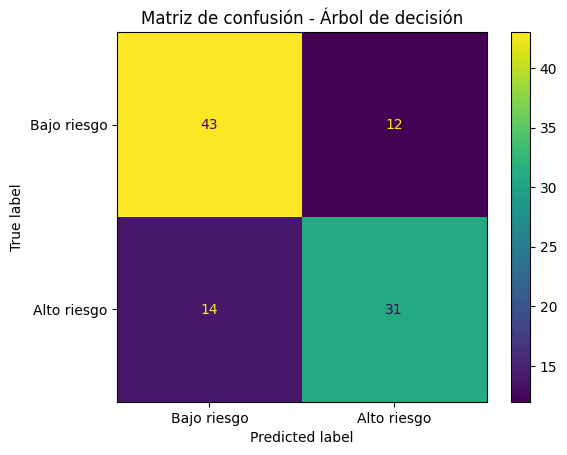

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Mostramos la matriz de confusión de manera visual.

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Bajo riesgo', 'Alto riesgo']
)

disp.plot()
plt.title("Matriz de confusión - Árbol de decisión")
plt.show()

In [35]:
# ============================================================
# 6.2 SELECCIÓN DE VARIABLES
# ============================================================

# Seleccionamos únicamente las variables relacionadas
# con el perfil financiero de las solicitudes.

variables_financieras = [
    'ingreso_mensual',
    'historial_crediticio',
    'creditos_activos',
    'utilizacion_credito',
    'pagos_atrasados',
    'monto_solicitado'
]

X_cluster = df[variables_financieras]

# Mostramos las primeras filas para comprobar
# que seleccionamos correctamente las variables.

X_cluster.head()

,ingreso_mensual,historial_crediticio,creditos_activos,utilizacion_credito,pagos_atrasados,monto_solicitado
0,31311,739,3,51.1,0.0,22209
1,10068,723,2,44.1,2.0,3000
2,36237,755,4,45.5,0.0,32517
3,11575,633,4,13.6,0.0,3141
4,10311,706,1,56.3,1.0,3858


In [36]:
# ============================================================
# 6.3 ESCALAMIENTO DE VARIABLES
# ============================================================

from sklearn.preprocessing import StandardScaler

# Creamos el escalador.
scaler = StandardScaler()

# Ajustamos el escalador a nuestros datos y transformamos
# las variables para que tengan una escala comparable.

X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Variables escaladas correctamente.")
print("Dimensiones de los datos:", X_cluster_scaled.shape)

Variables escaladas correctamente.
Dimensiones de los datos: (500, 6)


In [37]:
# ============================================================
# 6.4 CONSTRUCCIÓN DE GRUPOS MEDIANTE K-MEANS
# ============================================================

from sklearn.cluster import KMeans

# Creamos el modelo K-Means.
# Indicamos que queremos encontrar 2 grupos.

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Entrenamos K-Means utilizando los datos escalados.

kmeans.fit(X_cluster_scaled)

print("Modelo K-Means entrenado correctamente.")

Modelo K-Means entrenado correctamente.


In [38]:
# Guardamos el grupo asignado por K-Means a cada solicitud.

df['grupo'] = kmeans.labels_

print("Grupos asignados correctamente.")
print(df['grupo'].value_counts().sort_index())

Grupos asignados correctamente.
grupo
0     96
1    404
Name: count, dtype: int64


In [41]:
# ============================================================
# 6.5 ANÁLISIS DE LOS GRUPOS
# ============================================================

# Calculamos el promedio de cada variable financiera
# para cada uno de los grupos encontrados por K-Means.

promedios_grupos = df.groupby('grupo')[variables_financieras].mean()

promedios_grupos

,ingreso_mensual,historial_crediticio,creditos_activos,utilizacion_credito,pagos_atrasados,monto_solicitado
grupo,,,,,,
0,36476.364583,672.260417,2.447917,40.211458,1.260417,40570.260417
1,16931.532178,688.856436,2.150990,44.066337,0.980198,14427.319307


In [42]:
# ============================================================
# 7.4 SIMULACIÓN DEL APRENDIZAJE POR REFUERZO
# ============================================================

# Definimos los estados:
# 0 = Bajo riesgo
# 1 = Alto riesgo

estados = ['Bajo riesgo', 'Alto riesgo']

# Definimos las acciones:
# 0 = Rechazar
# 1 = Revisar
# 2 = Aprobar

acciones = ['Rechazar', 'Revisar', 'Aprobar']

# Definimos las recompensas para cada combinación
# de estado y acción.
#
# Filas:
# 0 = Bajo riesgo
# 1 = Alto riesgo
#
# Columnas:
# 0 = Rechazar
# 1 = Revisar
# 2 = Aprobar

recompensas = [
    [-3, 1, 10],    # Bajo riesgo
    [8, 1, -10]     # Alto riesgo
]

print("Tabla de recompensas:")
print()
print("                 Rechazar   Revisar   Aprobar")
print(f"Bajo riesgo       {recompensas[0][0]:>4}       {recompensas[0][1]:>4}       {recompensas[0][2]:>4}")
print(f"Alto riesgo       {recompensas[1][0]:>4}       {recompensas[1][1]:>4}       {recompensas[1][2]:>4}")

Tabla de recompensas:

                 Rechazar   Revisar   Aprobar
Bajo riesgo         -3          1         10
Alto riesgo          8          1        -10


In [43]:
# ============================================================
# 7.5 CONSTRUCCIÓN DE LA TABLA Q
# ============================================================

import numpy as np

# Creamos una tabla de 2 filas y 3 columnas.
#
# Filas:
# 0 = Bajo riesgo
# 1 = Alto riesgo
#
# Columnas:
# 0 = Rechazar
# 1 = Revisar
# 2 = Aprobar

tabla_q = np.zeros((2, 3))

print("Tabla Q inicial:")
print(tabla_q)

Tabla Q inicial:
[[0. 0. 0.]
 [0. 0. 0.]]


In [44]:
# ============================================================
# 7.6 EXPERIMENTACIÓN
# ============================================================

# Número de veces que el agente tomará una decisión.
iteraciones = 20

# Tasa de aprendizaje.
# Indica cuánto influye una nueva experiencia
# sobre el valor que ya tenía la tabla Q.
alpha = 0.5

# Guardamos una copia de la tabla inicial para poder comparar.
tabla_q_inicial = tabla_q.copy()

# Realizamos varias experiencias.
for i in range(iteraciones):

    # Alternamos entre los dos estados para que
    # el agente tenga experiencias de ambos tipos.
    estado = i % 2

    # Elegimos la acción que actualmente tiene
    # el mayor valor Q para ese estado.
    accion = np.argmax(tabla_q[estado])

    # Obtenemos la recompensa correspondiente.
    recompensa = recompensas[estado][accion]

    # Actualizamos el valor Q.
    tabla_q[estado][accion] = (
        tabla_q[estado][accion]
        + alpha * (recompensa - tabla_q[estado][accion])
    )

print("Tabla Q inicial:")
print(tabla_q_inicial)

print("\nTabla Q después de la experimentación:")
print(tabla_q)

Tabla Q inicial:
[[0. 0. 0.]
 [0. 0. 0.]]

Tabla Q después de la experimentación:
[[-1.5         0.99804688  0.        ]
 [ 7.9921875   0.          0.        ]]
